In [225]:
import sys
sys.path.append('../src')

In [226]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from stock_prices import get_stock_prices, plot_stock_prices, split_train_test
from feature_extraction import add_state_column
from technical_indicator_classifier import TechnicalIndicatorClassifier
from hybrid_model import HybridModel
from simulation import simulate_trade

In [227]:
symbol = "^JKSE"
start_date = "2023-01-01"
split_date = "2024-12-31"
end_date = "2025-12-31"

$^JKSE: possibly delisted; no price data found  (1d 2023-01-01 -> 2023-01-02)


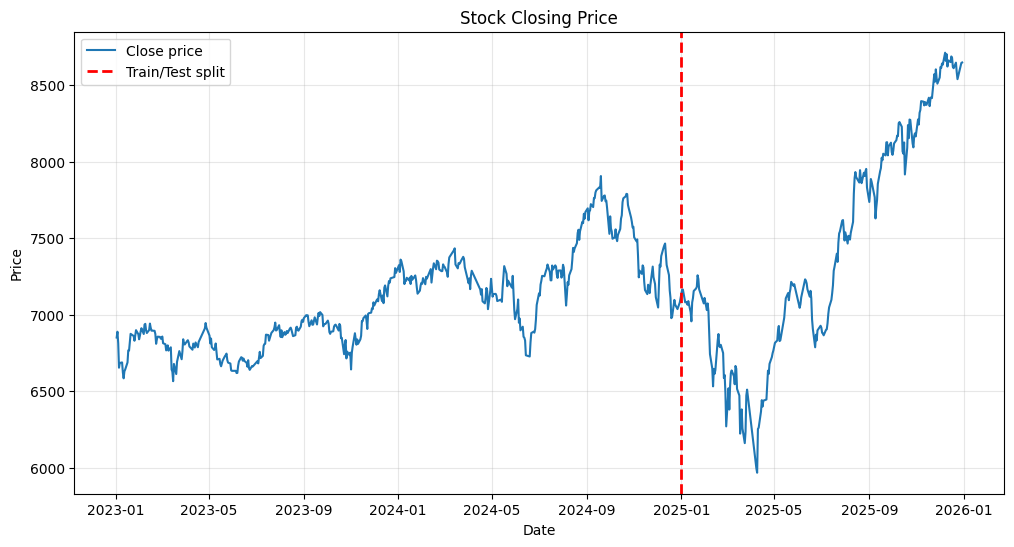

,symbol,date,open,high,low,close,volume,dividends,stock_splits
0,^JKSE,2023-01-02,6850.740234,6856.889160,6823.479004,6850.983887,109645000,0.0,0.0
1,^JKSE,2023-01-03,6850.983887,6908.001953,6838.574219,6888.757812,156894900,0.0,0.0
2,^JKSE,2023-01-04,6888.798828,6900.603027,6813.238770,6813.238770,142541400,0.0,0.0
3,^JKSE,2023-01-05,6813.279785,6813.421875,6621.986816,6653.840820,180589300,0.0,0.0
4,^JKSE,2023-01-06,6653.759766,6708.637207,6598.645996,6684.558105,109855600,0.0,0.0


In [228]:
stock_prices = get_stock_prices(symbol, start_date, end_date)
plot_stock_prices(stock_prices, split_date)
stock_prices.head()

In [229]:
add_state_column(stock_prices)
stock_prices_train, stock_prices_test = split_train_test(stock_prices, split_date)

In [230]:
method = "GaussianNB"
peek = 5
k = 9

In [231]:
classifier = TechnicalIndicatorClassifier(model = method, peek = peek)
classifier.train(stock_prices_train)

In [232]:
np.random.seed(5)
hybrid_model = HybridModel(k = k, classifier = classifier)
hybrid_model.train(stock_prices_train)

Epoch 301: Total reward = -0.091, Past Ten Total Rewards Std = 0.0219234035931571
Model stabilizes at epoch 301


True

Accumulated returns on training data:
Buy and hold return:  0.02197447712749434


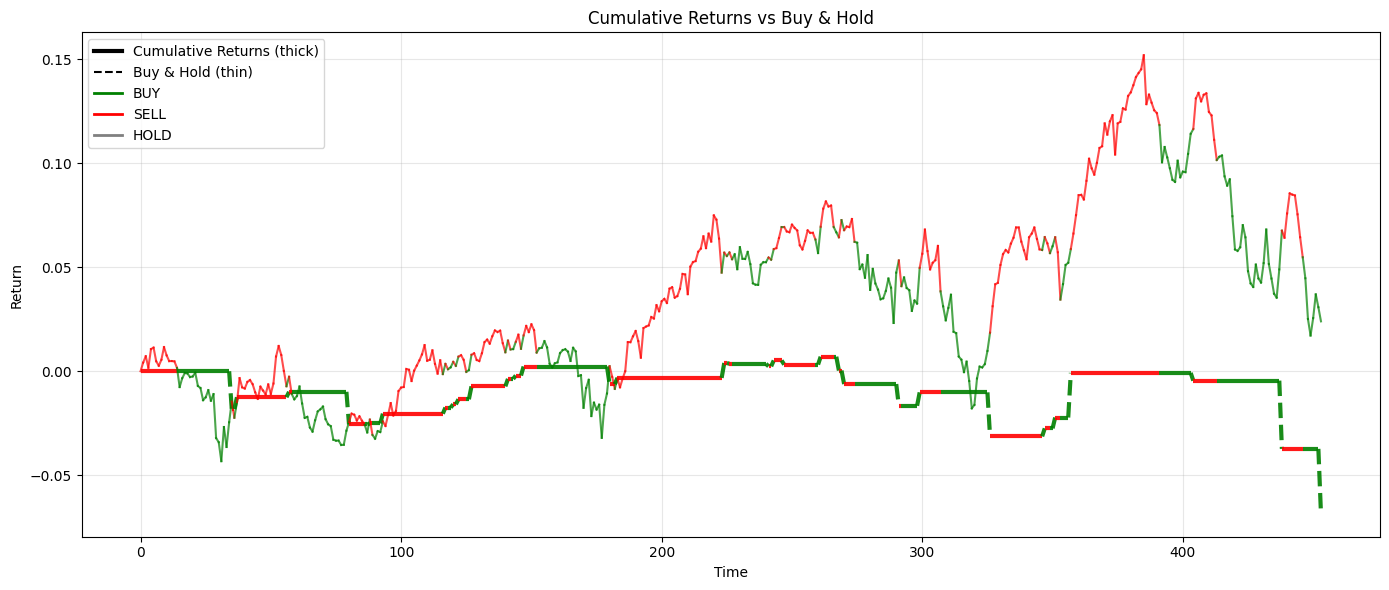

MA based return: -0.06851202503923706


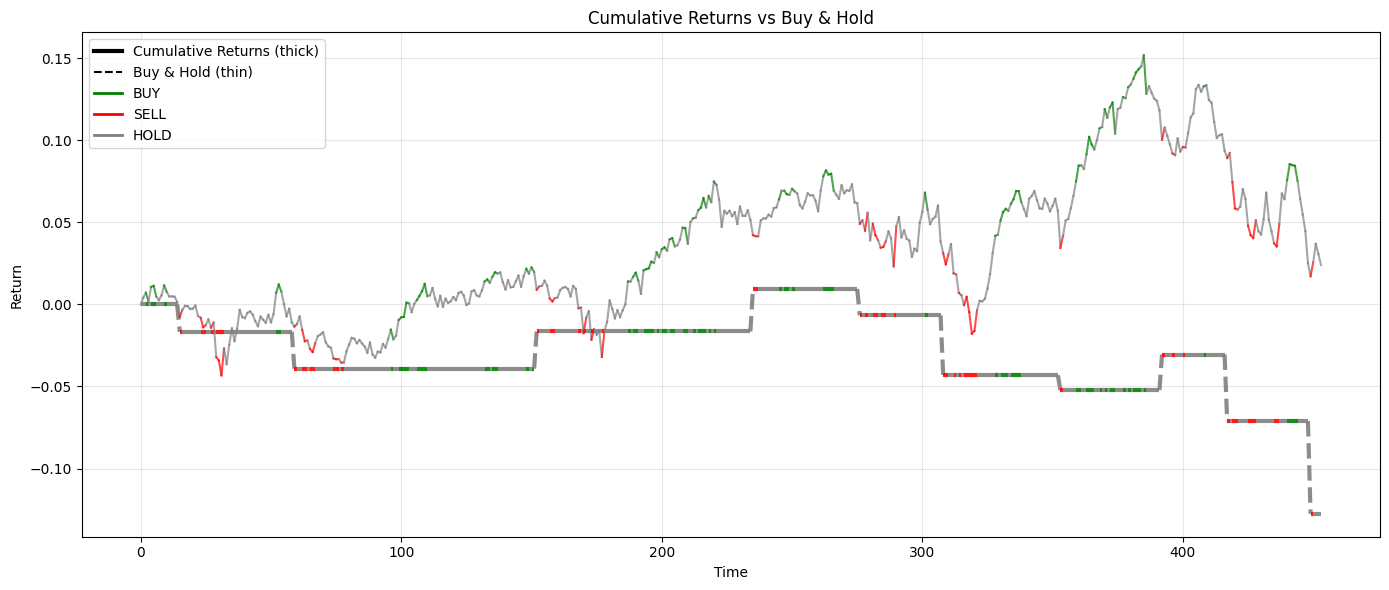

Breakout based return: -0.12758657477662538


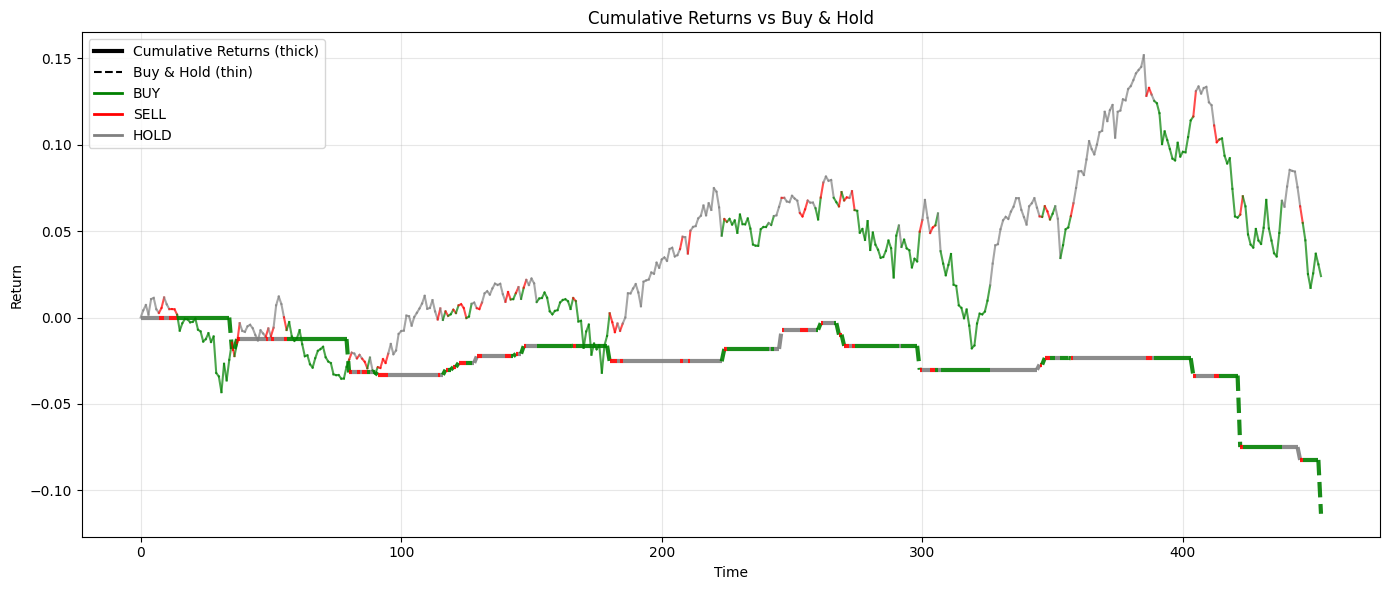

Classifier model return: -0.1136697330620802


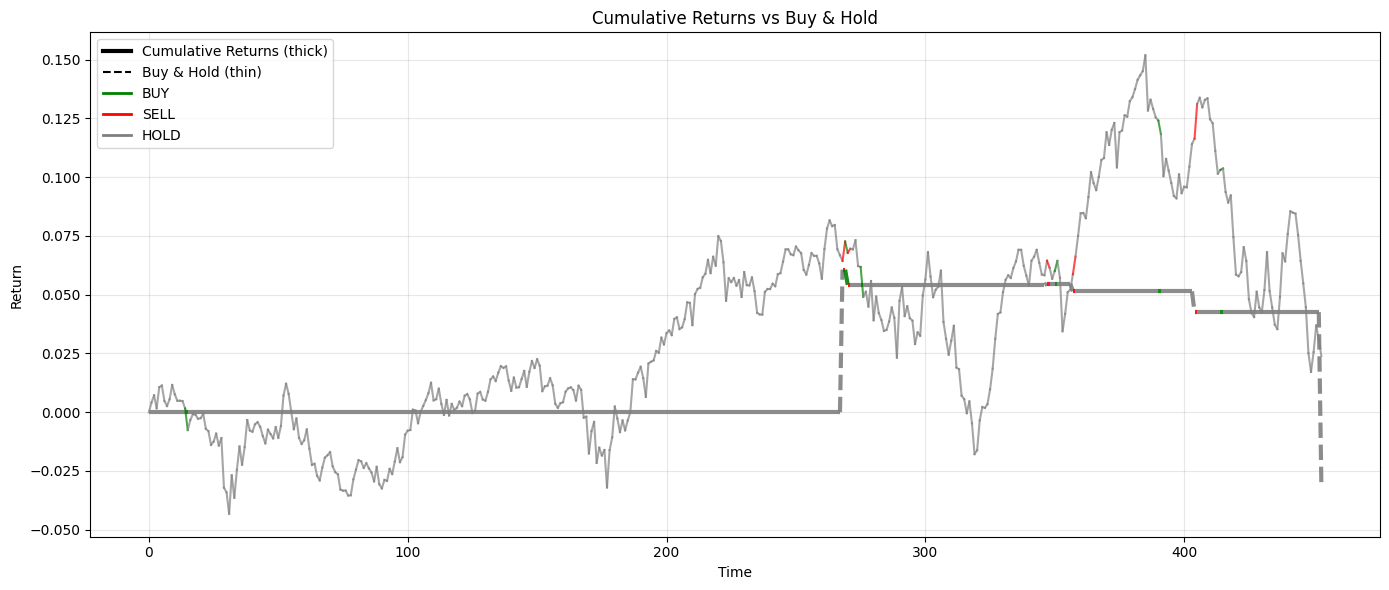

Hybrid model return: -0.03114269194831243


In [233]:
train_result = {}
print("Accumulated returns on training data:")
open_prices_train = stock_prices_train["open"].values[20:]

train_result["buy and hold"] = (open_prices_train[-1] / open_prices_train[1] - 1.002)
print("Buy and hold return: ", train_result["buy and hold"])

train_result["ma"] = simulate_trade(stock_prices_train, "ma", plot = True)
print("MA based return:", train_result["ma"])

train_result["breakout"] = simulate_trade(stock_prices_train, "breakout", plot = True)
print("Breakout based return:", train_result["breakout"])

train_result["classifier"] = simulate_trade(stock_prices_train, classifier, plot = True)
print("Classifier model return:", train_result["classifier"])

if k != 0:
    train_result["hybrid"] = simulate_trade(stock_prices_train, hybrid_model, plot = True)
    print("Hybrid model return:", train_result["hybrid"])

Accumulated returns on test data:
Buy and hold return:  0.20004819263993867


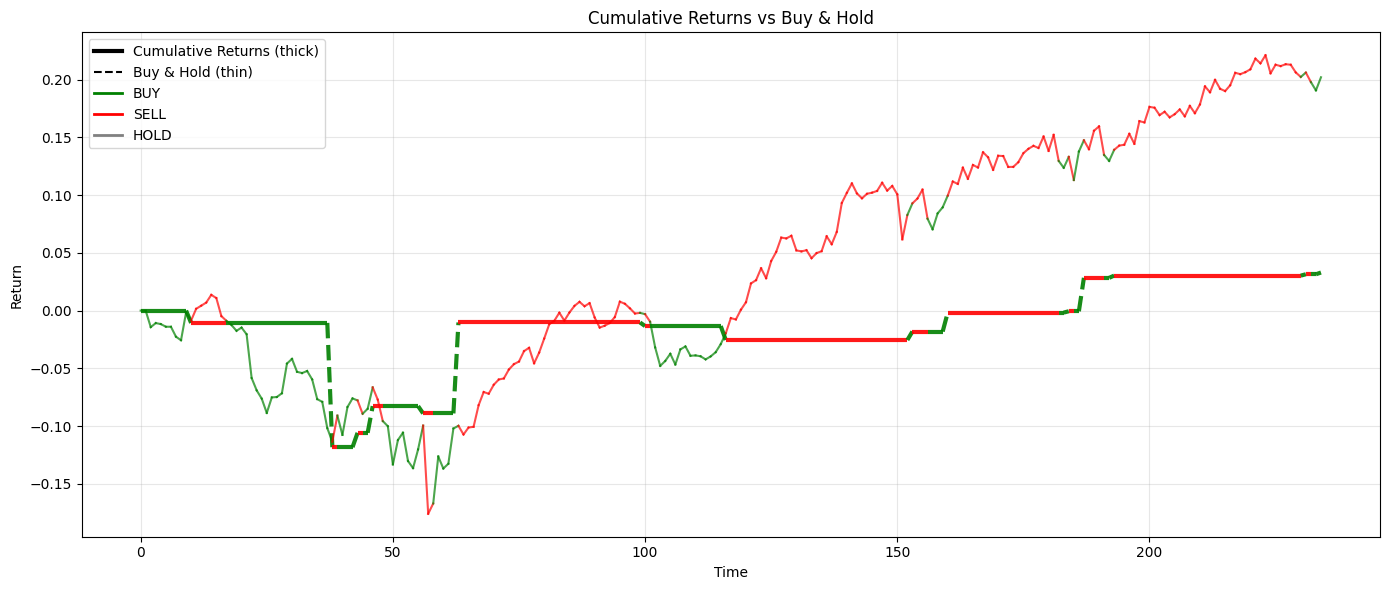

MA only return: 0.032950021869622585


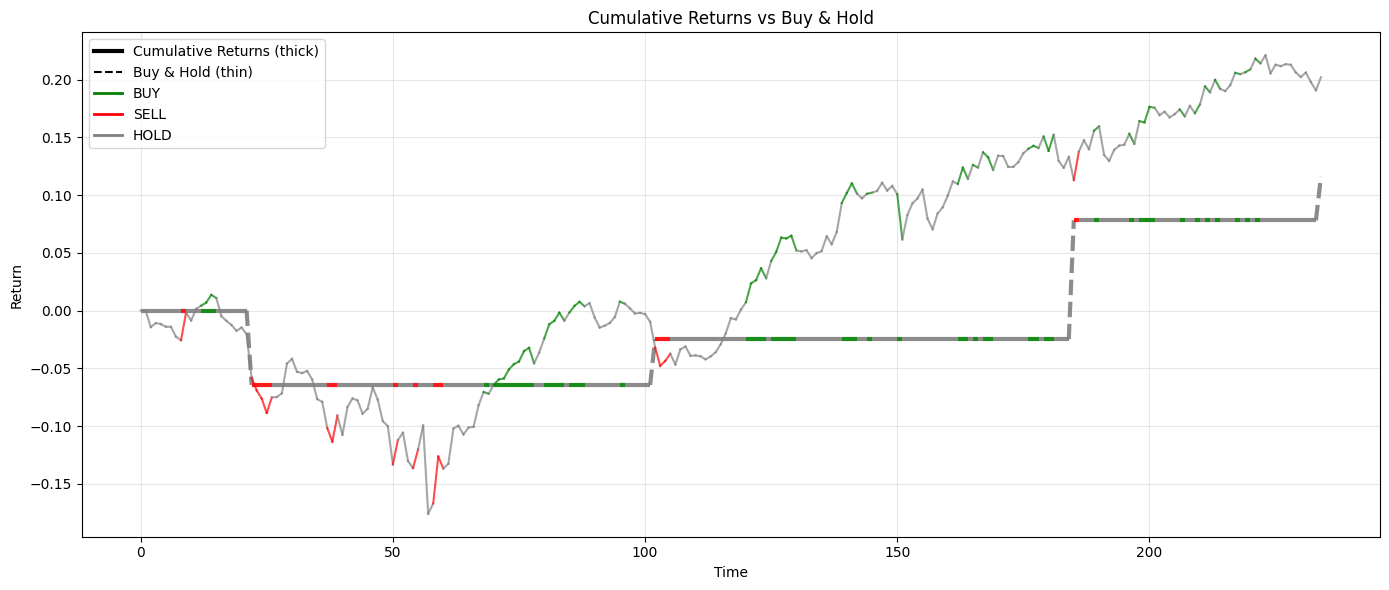

Breakout based return: 0.11629363672245516


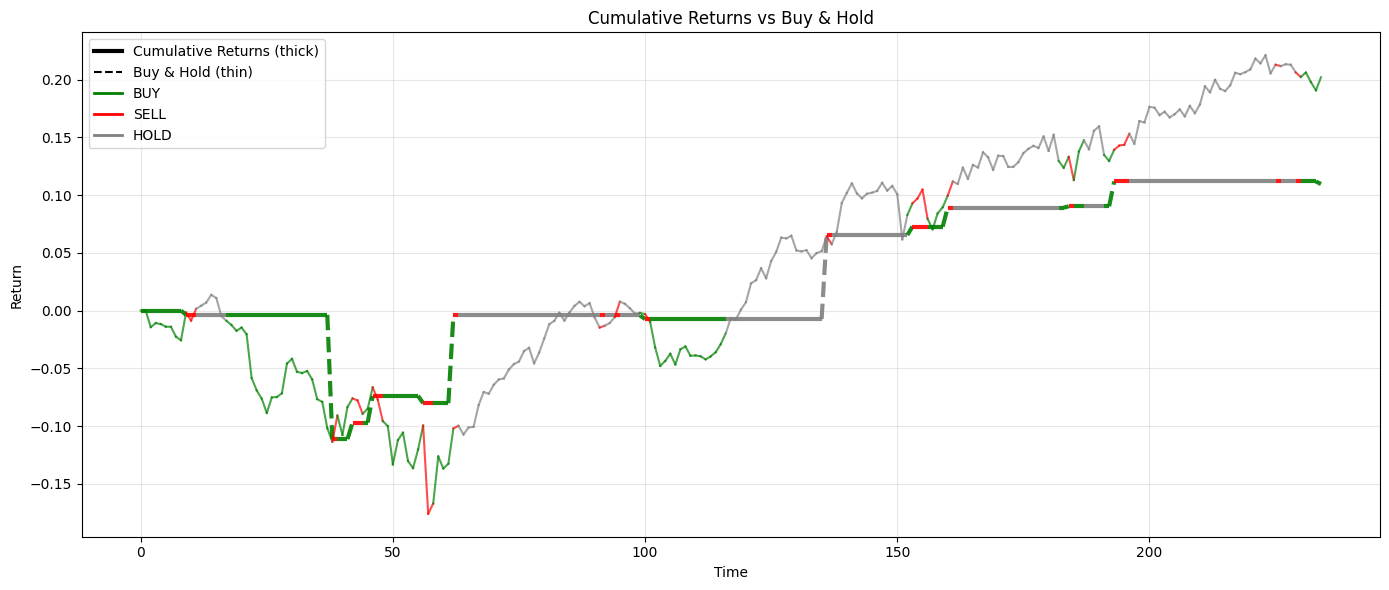

Classifier model return: 0.10959283958304188


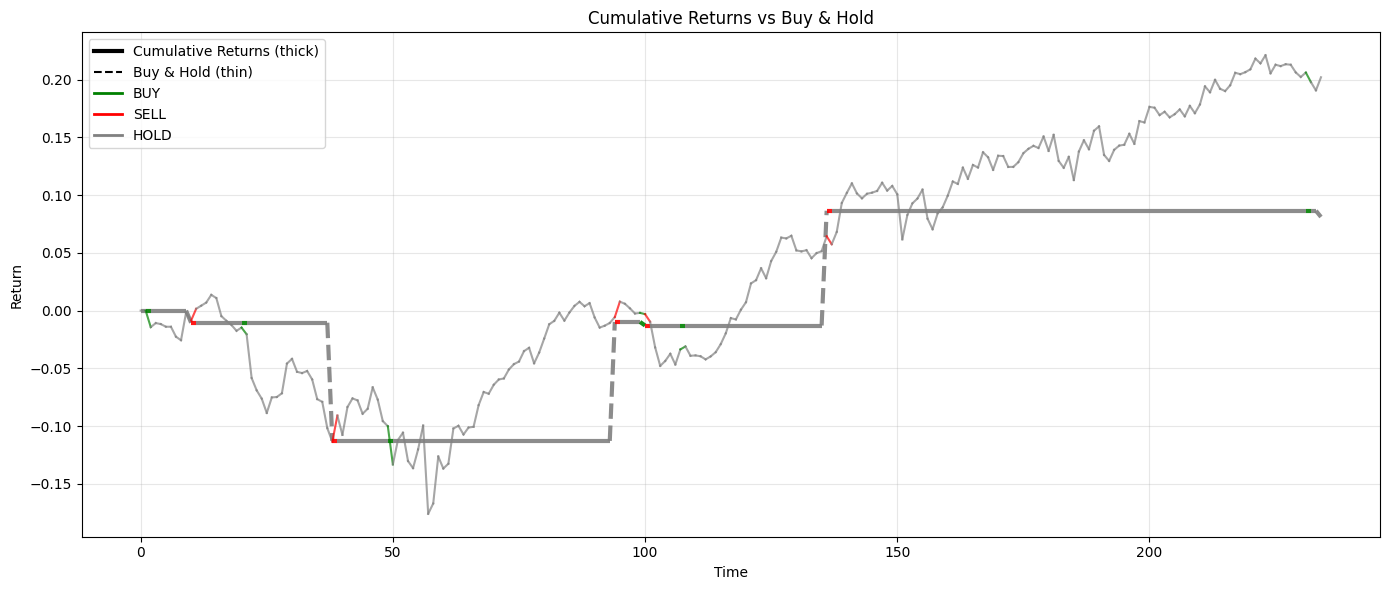

Hybrid model return: 0.08106565211982367


In [234]:
test_result = {}
print("Accumulated returns on test data:")
open_prices_test = stock_prices_test["open"].values[20:]

test_result["buy and hold"] = (open_prices_test[-1] / open_prices_test[1] - 1.002)
print("Buy and hold return: ", test_result["buy and hold"])

test_result["ma"] = simulate_trade(stock_prices_test, "ma", plot = True)
print("MA only return:", test_result["ma"])

test_result["breakout"] = simulate_trade(stock_prices_test, "breakout", plot = True)
print("Breakout based return:", test_result["breakout"])

test_result["classifier"] = simulate_trade(stock_prices_test, classifier, plot = True)
print("Classifier model return:", test_result["classifier"])

if k != 0:
    test_result["hybrid"] = simulate_trade(stock_prices_test, hybrid_model, plot = True)
    print("Hybrid model return:", test_result["hybrid"])

In [235]:
def run_iteration(i):
    np.random.seed(i)
    hybrid_model = HybridModel(k = k, classifier = classifier)
    stable = hybrid_model.train(stock_prices_train, show_log = False)
    trial = 1
    while not stable:
        stable = hybrid_model.train(stock_prices_train, show_log = False)
        trial += 1
        if trial == 10:
            print(f"Model failed to stabilize even after 10 trials (seed {i})")
            # Only account instance which achieves pseudo-convergence before max epochs
            return None
    test_ret = simulate_trade(stock_prices_test, hybrid_model, plot = False)
    return test_ret

results = Parallel(n_jobs = -1)(delayed(run_iteration)(i) for i in range(6, 21))
results = [result for result in results if result is not None]
hybrid_returns = np.array(results)

buy_hold_return = test_result["buy and hold"]

ma_return = test_result["ma"]
excess_ma = ma_return - buy_hold_return

break_out_return = test_result["breakout"]
excess_momentum = break_out_return - buy_hold_return

classifier_return = test_result["classifier"]
excess_classifier = classifier_return - buy_hold_return

mean_hybrid_return = np.mean(hybrid_returns)
hybrid_excess_returns = hybrid_returns - buy_hold_return
excess_hybrid = mean_hybrid_return - buy_hold_return
excess_hybrid_std =  np.std(hybrid_excess_returns)

# Create dataframe with 8 columns
results_df = pd.DataFrame({
    'Buy and Hold': [buy_hold_return],
    'MA Based': [ma_return],
    'Breakout Based': [break_out_return],
    'Classifier Model': [classifier_return],
    'Mean Hybrid Model': [mean_hybrid_return],
    'Excess MA': [excess_ma],
    'Excess Breakout': [excess_momentum],
    'Excess Classifier': [excess_classifier],
    'Excess Hybrid': [excess_hybrid],
    'Excess Hybrid Std': [excess_hybrid_std],
    'Number of Samples': len(hybrid_returns)
})

display(results_df)

results_df.to_parquet(f"results/{symbol[:4]}.parquet", engine = "pyarrow")

,Buy and Hold,MA Based,Breakout Based,Classifier Model,Mean Hybrid Model,Excess MA,Excess Breakout,Excess Classifier,Excess Hybrid,Excess Hybrid Std,Number of Samples
0,0.200048,0.03295,0.116294,0.109593,0.131352,-0.167098,-0.083755,-0.090455,-0.068696,0.058078,15
